In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import glob
import numpy as np

In [3]:
ea = EventAccumulator("/home/kang/multiagent-quadruped-environment/training-log/MQE-Curriculum/go1gate/1_Individual Navigation to Gate(07-20_16-17)_sample_0/tensorboard/events.out.tfevents.1753053491.kang-iconlab")
ea.Reload()  # loads events from file

print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['average_step_reward', 'Reward/agent_0_progress', 'Reward/agent_1_progress', 'Reward/agent_0_close_to_gate', 'Reward/agent_1_close_to_gate', 'Reward/safe_distance', 'Reward/small_command', 'value_loss', 'policy_loss', 'dist_entropy', 'actor_grad_norm', 'critic_grad_norm', 'ratio'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


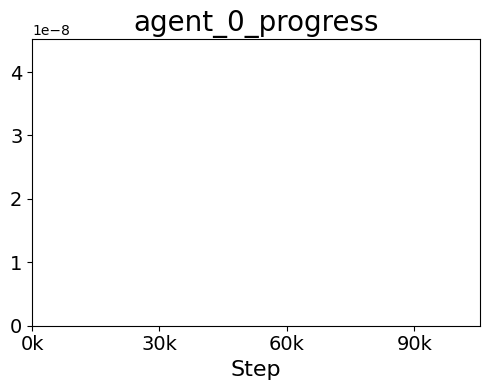

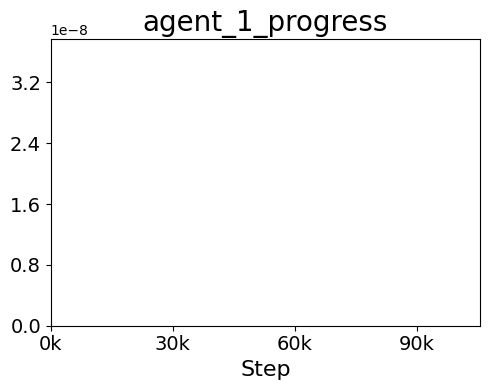

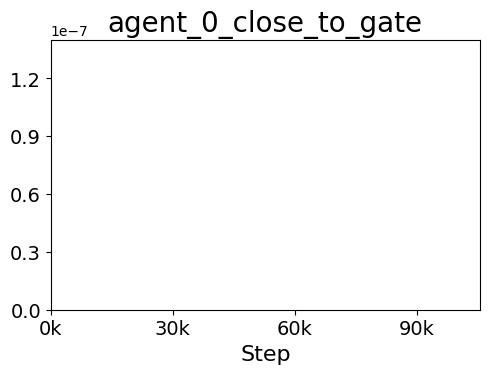

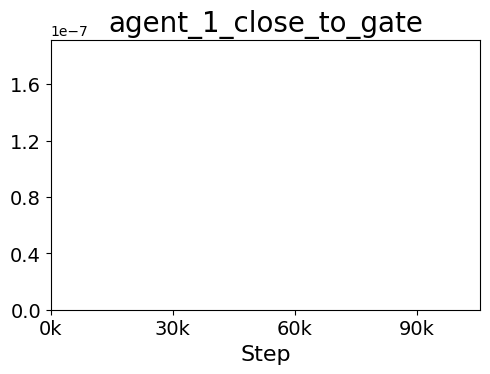

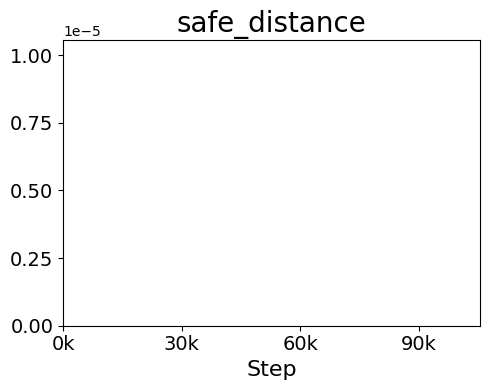

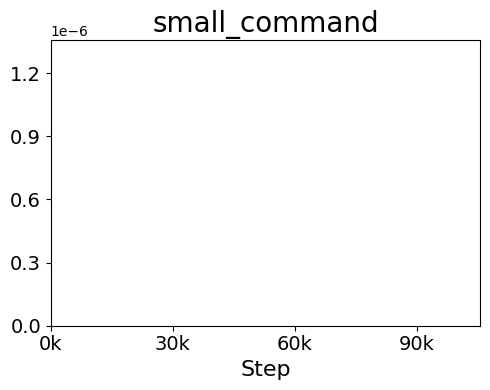

In [4]:
# Collect reward curve - save than reload (easier this way)
curve_img_path = []
for tag in ea.Tags()["scalars"]:
    if 'Reward' in tag:
        reward_curve = []
        for scalar in ea.Scalars(tag):
            reward_curve.append([scalar.step, scalar.value])
        reward_curve = np.array(reward_curve)  
        # name = tag.removeprefix('Info / ')
        def remove_prefix(text, prefix):
            if text.startswith(prefix):
                return text[len(prefix):]
            return text
        name = remove_prefix(tag, 'Reward/')
        # name = tag

        plt.figure(figsize=(5, 4))
        plt.plot(reward_curve[:, 0], reward_curve[:, 1])
        plt.xlabel('Step', fontsize=16)
        plt.title(f"{name}", fontsize=20)
        ax = plt.gca()
        ax.set_xlim(left=0)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))
        ax.set_ylim(bottom=0)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=False))
        ax.tick_params(axis='both', which='major', labelsize=14)

        plt.tight_layout()
        img_path = "test.png"
        plt.savefig(img_path)
        curve_img_path.append(img_path)

In [6]:
import pickle
def open_curriculum():
    # Open curriculum pkl file
    file_path = "/home/kang/multiagent-quadruped-environment/logs/seed_0/07-18_18-26/curriculum.pkl"
    with open(file_path, 'rb') as file:
        curriculum = pickle.load(file)
        curriculum_length = len(curriculum)

        # for task_detail in curriculum:
        #     task_detail['Name'] = f'{task_detail["Task_num"]}_{task_detail["Subtask"]}'
        
        print(f"Curriculum loaded from {file_path}")
        print(curriculum)

open_curriculum()

Curriculum loaded from /home/kang/multiagent-quadruped-environment/logs/seed_0/07-18_18-26/curriculum.pkl
[{}, {'Task_num': '1', 'Subtask': 'Alignment and Safe Approaching', 'Name': '1_Alignment and Safe Approaching(07-18_18-26)', 'Description': 'Both agents should align themselves towards the gate center and approach while maintaining a safe distance from each other. The focus is on achieving optimal heading alignment using their yaw angles and keeping their distance above 0.25 to avoid immediate collisions. Reward based on alignment precision with the gate center and safe inter-agent distance.  ', 'Reason': 'Proper alignment and maintaining a safe distance are crucial to avoid early collisions and establish a foundation for passing through narrow spaces. This task prepares agents for optimal entrance into the gate.'}, {'Task_num': '2', 'Subtask': 'Sequential Gate Passage Practice', 'Name': '2_Sequential Gate Passage Practice(07-18_18-26)', 'Description': "Train the agents to pass thr